---
# CNN : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.datasets import mnist

2025-10-02 14:13:19.006740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 14:13:19.073887: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-02 14:13:20.546853: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 1. Données
---

### 1.1. Importation

In [7]:
test_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

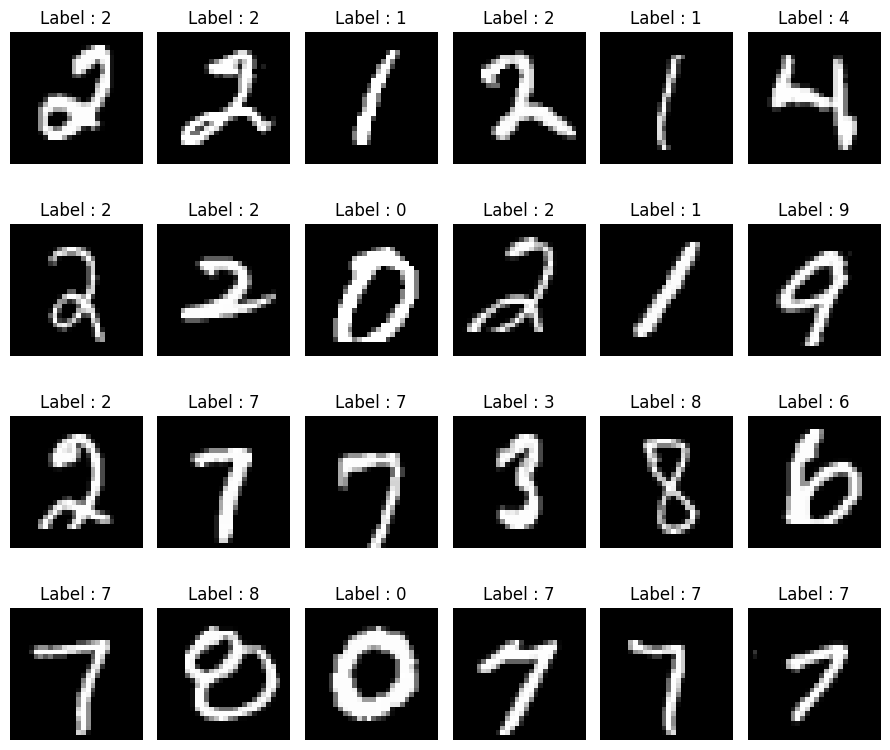

In [8]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [9]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. CNN
---

### 2.1. Architecture

In [10]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10

n_conv_1 = 8
n_conv_2 = 16

n_units_hl = 100

dropout_conv1 = 0.2
dropout_conv2 = 0.2
dropout_hl    = 0.2

model = models.Sequential(name='CNN')

model.add(layers.Input(shape=dim_inputs))

model.add(layers.Conv2D(filters=n_conv_1, kernel_size=(3, 3), activation='relu', name='Convolutive_1'))
model.add(layers.Dropout(rate=dropout_conv1, name='Dropout_Convolution_1'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_1'))

model.add(layers.Conv2D(filters=n_conv_2, kernel_size=(3, 3), name='Convolutive_2', activation='relu'))
model.add(layers.Dropout(rate=dropout_conv2, name='Dropout_Convolution_2'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_2'))

model.add(layers.Flatten())
model.add(layers.Dense(units=n_units_hl, activation='relu', name='Hidden_layer'))
model.add(layers.Dropout(rate=dropout_hl, name='Dropout_Hidden_layer'))

model.add(layers.Dense(units=dim_outputs, activation='softmax'))

model.summary()

2025-10-02 14:15:27.726964: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolutive_1 (Conv2D)          │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Convolution_1 (Dropout) │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_pooling_1 (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolutive_2 (Conv2D)          │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Convolution_2 (Dropout) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_pooling_2 (MaxPooling2D)    │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer (Dense)            │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer (Dropout)  │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,358 (165.46 KB)

 Trainable params: 42,358 (165.46 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [11]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [12]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8133 - loss: 0.6196 - val_accuracy: 0.9463 - val_loss: 0.2429
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9467 - loss: 0.1793 - val_accuracy: 0.9652 - val_loss: 0.1438
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9607 - loss: 0.1308 - val_accuracy: 0.9741 - val_loss: 0.1096
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9687 - loss: 0.1038 - val_accuracy: 0.9781 - val_loss: 0.0923
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9734 - loss: 0.0893 - val_accuracy: 0.9794 - val_loss: 0.0812
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9755 - loss: 0.0793 - val_accuracy: 0.9815 - val_loss: 0.0705
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9783 - loss: 0.0700 - val_accuracy: 0.9836 - val_loss: 0.0659
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9796 - loss: 0.0652 - val_accu

### 2.4. Prévisions

In [13]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[9.59293622e-09, 8.76678882e-07, 2.52540140e-05, 2.05468223e-05,
        2.41170515e-08, 4.83973084e-09, 3.52549483e-11, 9.99951780e-01,
        2.12199197e-07, 1.38335383e-06],
       [1.42051613e-05, 1.22846586e-05, 9.99973357e-01, 1.11690412e-09,
        1.07995246e-09, 1.31151719e-12, 9.76053087e-08, 2.12940776e-08,
        9.04365416e-10, 1.15677485e-11],
       [3.04714126e-06, 9.99493301e-01, 2.12246214e-05, 2.27132816e-07,
        1.78173155e-04, 4.28754220e-06, 1.44452861e-04, 1.08709806e-04,
        4.61868622e-05, 4.94409051e-07],
       [9.96163428e-01, 7.44048918e-07, 1.86273737e-05, 7.64886238e-07,
        1.42094802e-06, 5.51510966e-05, 3.55193508e-03, 1.77999345e-06,
        4.82075939e-06, 2.01339950e-04],
       [7.02344721e-07, 2.66241841e-07, 2.29971391e-07, 1.23703245e-07,
        9.97684121e-01, 5.22693142e-08, 1.92283395e-07, 4.50753191e-07,
        1.29973694e-06, 2.31240597e-03]], dtype=float32)

In [14]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [15]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0283
Exactitude test : 0.9910
